# Mean daily source water dynamics

In [1]:
import xarray as xr
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [11]:
data = pd.read_csv('/ocean/rbeutel/MOAD/analysis-becca/projections/combineddata.csv').drop(columns="Unnamed: 0")
data['date'] = pd.to_datetime(data.date)

In [ ]:
# want to add a column indicating which source water that source water comes from
bdy_loo = 0
bdy_sou = 2
bdy_off = 3
bdy_nor = 4
saltdiv = 32
sdiv = 33.5

freshbool = ((data.section==bdy_sou) & (data.salt < saltdiv))
cucbool = ((data.section==bdy_sou) & (data.salt >= sdiv))
southbool = ((data.section==bdy_sou) & (data.salt >= saltdiv) & (data.salt < sdiv))
northbool = (data.section==bdy_nor)
offshore_dbool = ((data.section==bdy_off) & (data.Fdepth > 120))
offshore_sbool = ((data.section==bdy_off) & (data.Fdepth <=120))
loopbool = ((data.section==bdy_loo) & (abs(data.start-data.end) > 24))

data['source'] = np.nan
data['source'][freshbool] = 'fresh'
data['source'][cucbool] = 'cuc'
data['source'][southbool] = 'south'
data['source'][offshore_dbool] = 'offshore_d'
data['source'][offshore_sbool] = 'offshore_s'
data['source'][northbool] = 'north'
data['source'][loopbool] = 'loop'

# save as a category for faster comparison
data["source"] = data["source"].astype("category")

In [19]:
data

,date,start,end,section,Idepth,Fdepth,lon,lat,transport,salt,source
0,2013-11-13,2408.0,2306.277573,2.0,16.192689,3.438488,-124.547978,47.468866,303.159669,31.105961,fresh
1,2013-11-13,2408.0,2319.785245,2.0,19.699151,1.907283,-124.472854,47.468866,248.254126,29.523134,fresh
2,2013-11-13,2409.0,2306.272426,2.0,-0.364622,7.402451,-124.550437,47.468866,55.977753,31.234024,fresh
3,2013-11-13,2409.0,2193.241038,2.0,-0.359163,10.930170,-124.495305,47.468866,130.880503,32.200840,south
4,2013-11-13,2409.0,2209.679025,2.0,-0.339634,4.048908,-124.423215,47.468866,175.226405,31.977562,fresh
...,...,...,...,...,...,...,...,...,...,...,...
12679954,2023-10-13,2880.0,2744.543902,0.0,94.831099,33.527072,-124.379045,48.489580,301.456764,32.108730,loop
12679955,2023-10-13,2880.0,2787.989060,0.0,68.709381,42.144712,-124.379045,48.494390,310.652780,32.161076,loop
12679956,2023-10-13,2880.0,2822.958174,0.0,50.886433,22.345608,-124.379045,48.410228,318.123523,31.888180,loop
12679957,2023-10-13,2880.0,2769.931399,0.0,37.625616,29.028931,-124.379045,48.495056,157.253209,31.997681,loop


In [65]:
# spring and fall transition dates from Hourston and Thomson SOPO report

ht_dates = pd.read_csv('/ocean/rbeutel/MOAD/biogeo_paper/FRDR/observations/in_ttwcvi_rh10_rw.txt', skiprows=115, 
            names=['Record_Number','Date','Time','Spring Transition, Year','Spring Transition, Month','Spring Transition, Day','Spring Transition, Hour',
                   'Spring Transition, Minute', 'Spring Transition, Second' , 'Fall Transition, Year' , 'Fall Transition, Month', 'Fall Transition, Day' , 
                   'Fall Transition, Hour', 'Fall Transition, Minute' , 'Fall Transition, Second' , 'Spring Transition JD, Julian', 'Fall Transition JD, Julian', 
                   'Length of Upwelling Season', 'Length of Downwelling Season'], sep='\s+').drop(['Record_Number','Date','Time',
                                                                                                   'Spring Transition, Hour','Spring Transition, Minute', 'Spring Transition, Second',
                                                                                                   'Fall Transition, Year' ,'Fall Transition, Hour', 'Fall Transition, Minute' , 
                                                                                                   'Fall Transition, Second'],axis=1).rename(columns={'Spring Transition, Year':'Year'})
ht_dates['spring'] = [dt.datetime(year=int(ht_dates['Year'][i]),month=int(ht_dates['Spring Transition, Month'][i]),day=int(ht_dates['Spring Transition, Day'][i])) for i in range(len(ht_dates))]
ht_dates['fall'] = [dt.datetime(year=int(ht_dates['Year'][i]),month=int(ht_dates['Fall Transition, Month'][i]),day=int(ht_dates['Fall Transition, Day'][i])) for i in range(len(ht_dates))]

spring = np.array(ht_dates.spring[(ht_dates.Year>=2018)&(ht_dates.Year<=2022)])
fall = np.array(ht_dates.fall[(ht_dates.Year>=2018)&(ht_dates.Year<=2022)])

In [89]:
def transport_array(data, depthrange, source, *, startday=dt.datetime(2018,1,1), endday=dt.datetime(2022,12,31), window=4, average=False):
    # Create a an array of daily transport from a particular source water within a given depth range
    # depthrange should be a list with the min depth in the 0 location and the max depth in the 1 location

    dates = pd.date_range(start=startday,end=endday, freq="D")

    # Filter dataset
    if source=='total':
        mask = (
            (data["Idepth"] > depthrange[0]) &
            (data["Idepth"] <= depthrange[1]) &
            (data["date"] >= startday) &
            (data["date"] <= endday)
        )
    else: 
        mask = (
            (data["source"] == source) &
            (data["Idepth"] > depthrange[0]) &
            (data["Idepth"] <= depthrange[1]) &
            (data["date"] >= startday) &
            (data["date"] <= endday)
        )

    # Sum once by day
    daily = (
        data.loc[mask]
        .groupby("date", sort=True)["transport"]
        .sum()
        .div(24)
        .reindex(dates, fill_value=0.0)
    )

    transport_daily = daily.to_numpy()

    if average == True:
        transport_daily = moving_average(transport_daily,window)

    return transport_daily, dates

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

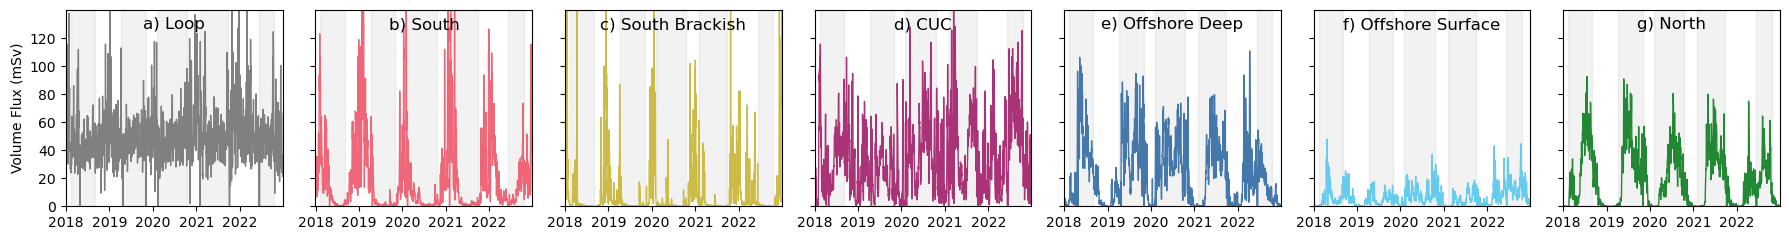

In [80]:
# plot data from each water mass over the full water column
ymax=140000
depthrange=[0,240]
startday=dt.datetime(2018,1,1) 
endday=dt.datetime(2022,12,31)

fig, ax = plt.subplots(1,7, figsize=(18,2.5))

# loop flow
transport, dates = transport_array(data, depthrange, "loop")
ax[0].plot(dates,transport,'grey',lw=1)
ax[0].set_title('a) Loop',y=1,pad=-14)

# south shelf flow
transport, _ = transport_array(data, depthrange, "south")
ax[1].plot(dates,transport,'#EE6677',lw=1)
ax[1].set_title('b) South',y=1,pad=-14)

# south brackish flow
transport, _ = transport_array(data, depthrange, "fresh")
ax[2].plot(dates,transport,'#CCBB44',lw=1)
ax[2].set_title('c) South Brackish',y=1,pad=-14)

# cuc flow
transport, _ = transport_array(data, depthrange, "cuc")
ax[3].plot(dates,transport,'#AA3377',lw=1)
ax[3].set_title('d) CUC',y=1,pad=-14)

# offshore deep flow
transport, _ = transport_array(data, depthrange, "offshore_d")
ax[4].plot(dates,transport,'#4477AA',lw=1)
ax[4].set_title('e) Offshore Deep',y=1,pad=-14)

# offshore surface flow
transport, _ = transport_array(data, depthrange, "offshore_s")
ax[5].plot(dates,transport,'#66CCEE',lw=1)
ax[5].set_title('f) Offshore Surface',y=1,pad=-14)

# north flow
transport, _ = transport_array(data, depthrange, "north")
ax[6].plot(dates,transport,'#228833',lw=1)
ax[6].set_title('g) North',y=1,pad=-14)


for i in range(len(ax)):
    # highlight upwelling periods based on Hourston and Thomson SOPO results
    for j in range(len(spring)):
        ax[i].fill_between(dates, 0, ymax, where=(dates<fall[j])&(dates>=spring[j]), color='grey', alpha=0.1)

    #general formatting
    ax[i].set_yticks([0,20000,40000,60000,80000,100000,120000])
    ax[i].set_yticklabels([])
    ax[i].set_ylim([0,ymax])
    ax[i].set_xlim([startday,endday])
    ax[i].set_xticks(pd.date_range(start=startday-dt.timedelta(days=365),end=endday-dt.timedelta(days=365), freq="Y")+dt.timedelta(days=1)+dt.timedelta(days=1))
    ax[i].set_xticklabels([2018,2019,2020,2021,2022])
ax[0].set_yticklabels(['0','20','40','60','80','100','120'])
ax[0].set_ylabel('Volume Flux (mSv)')

plt.tight_layout()

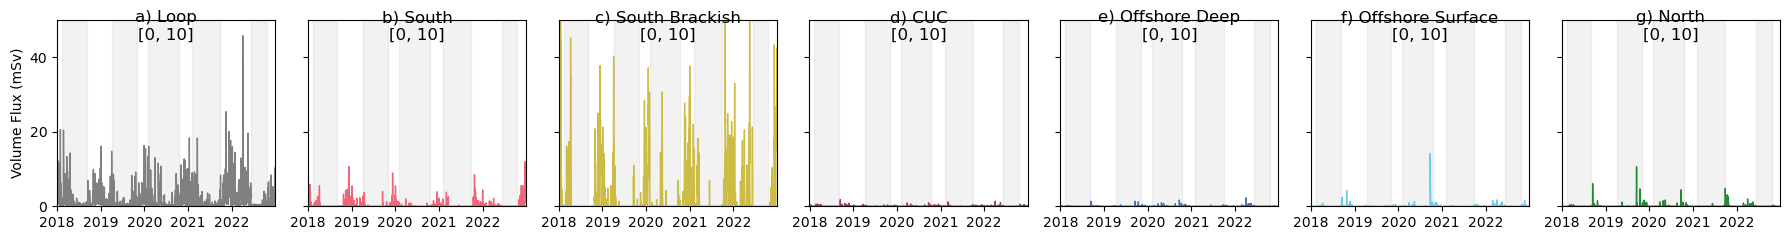

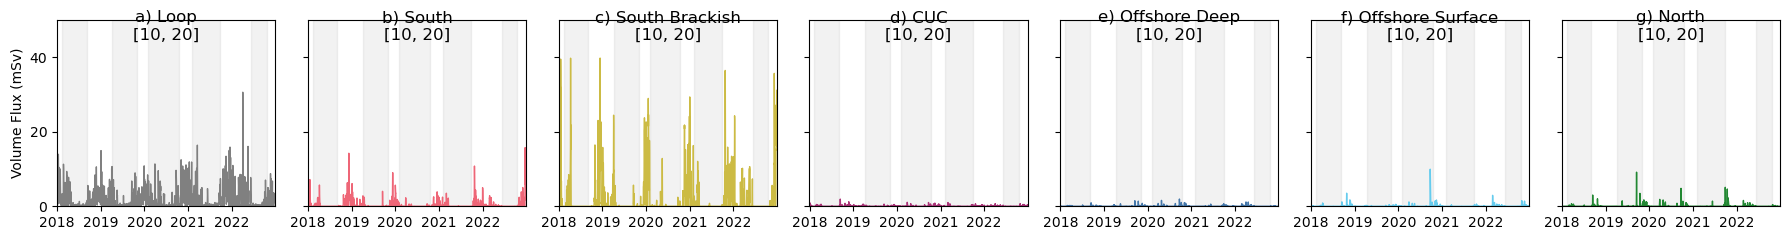

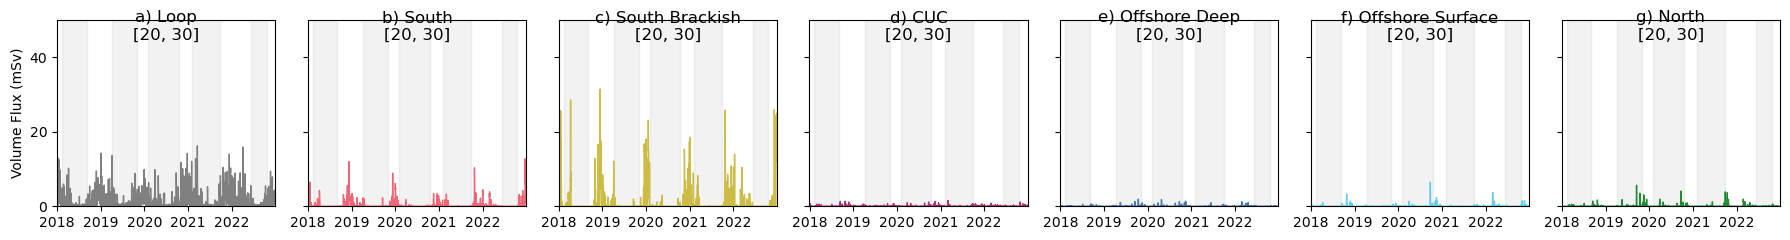

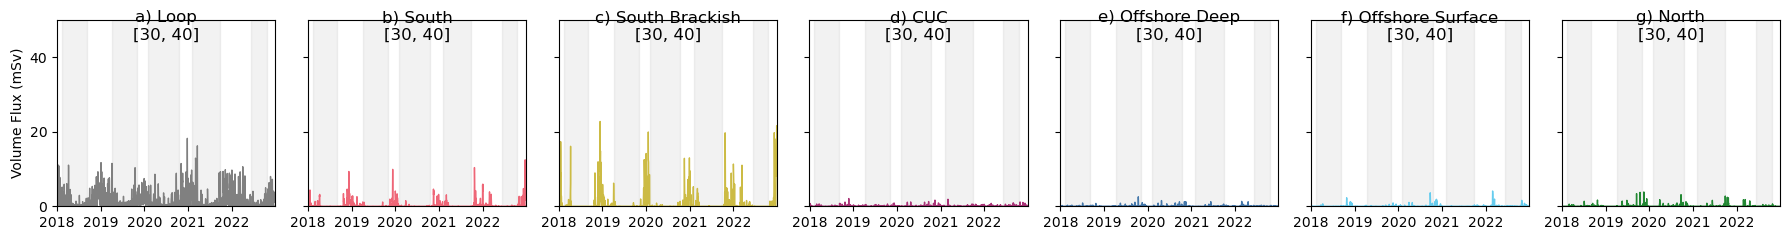

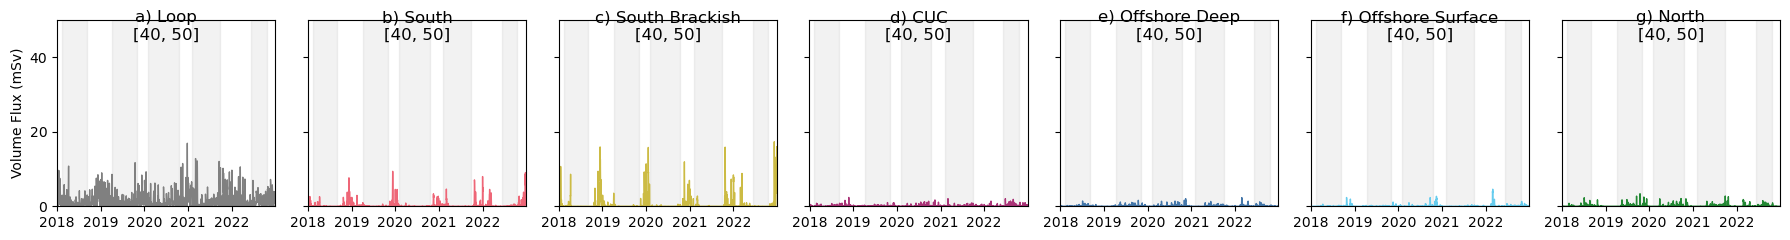

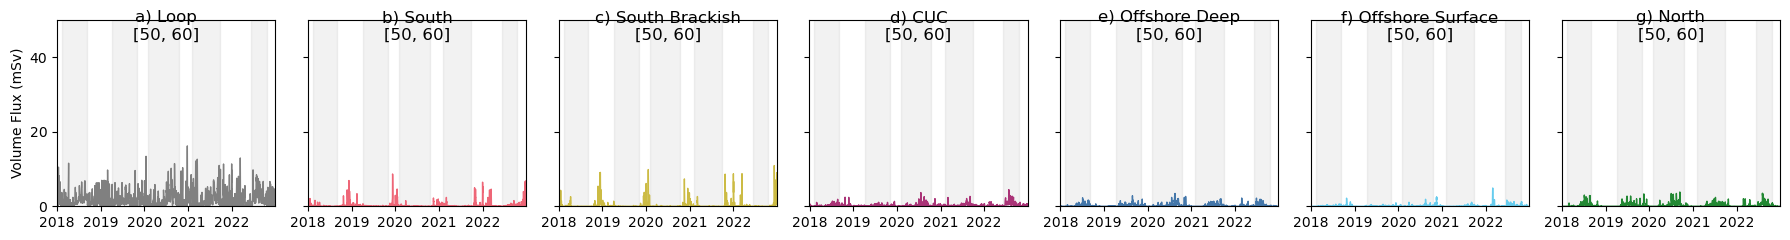

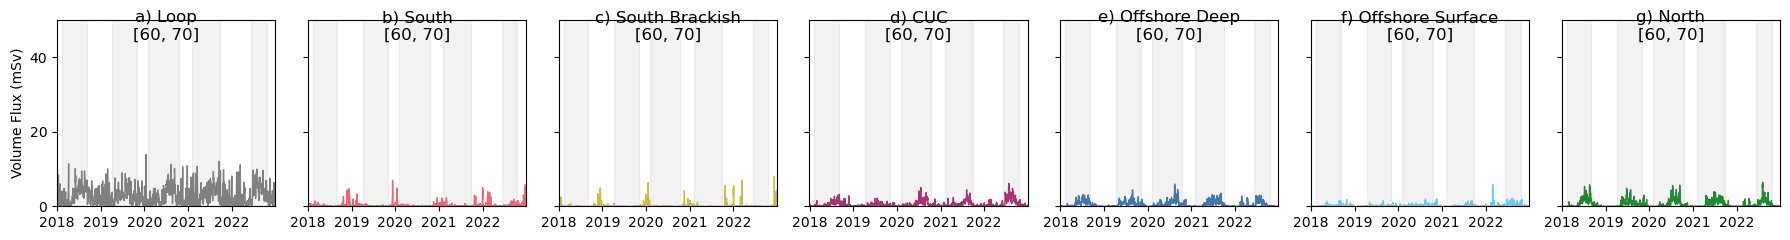

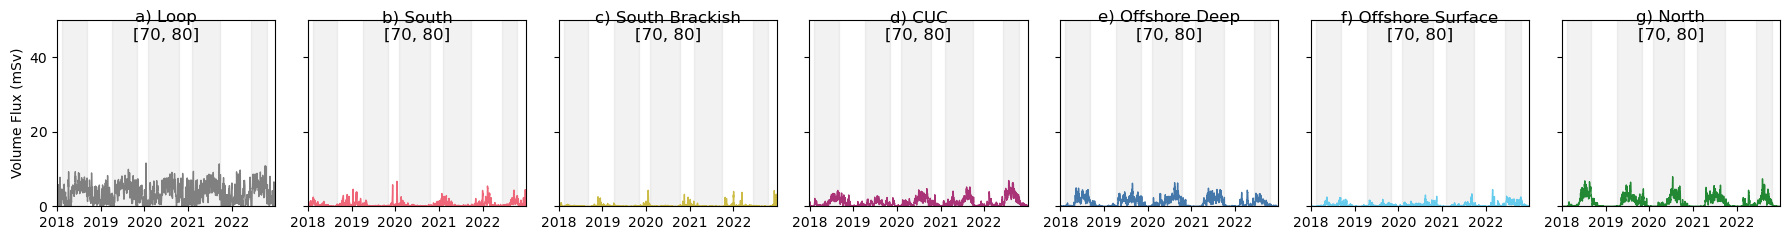

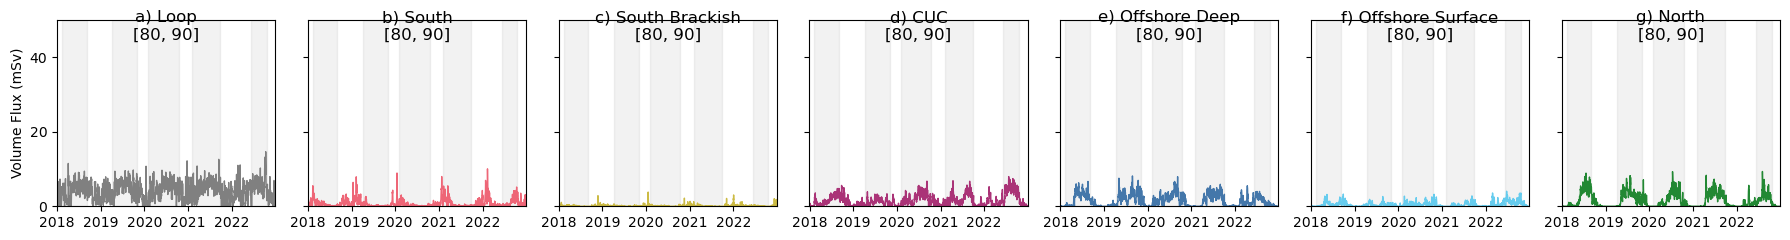

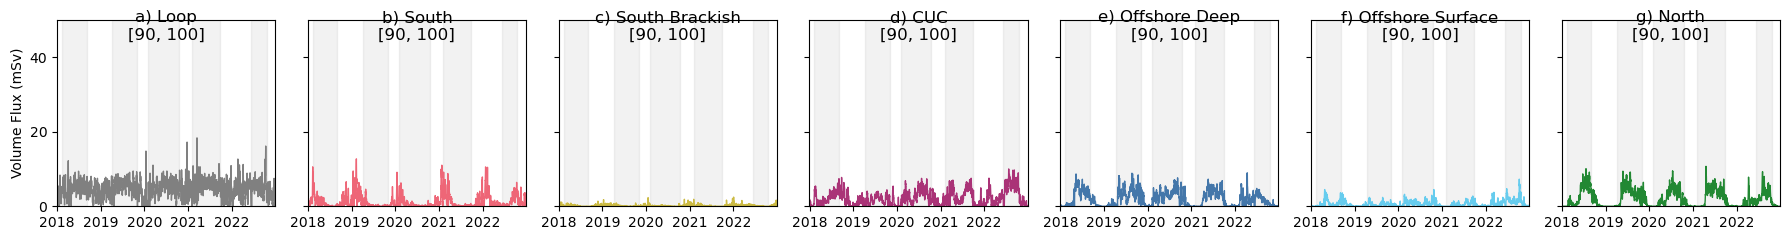

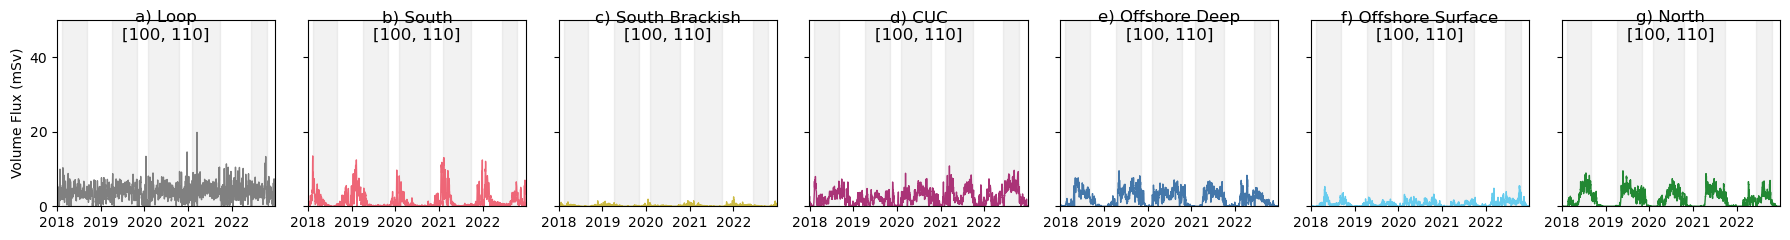

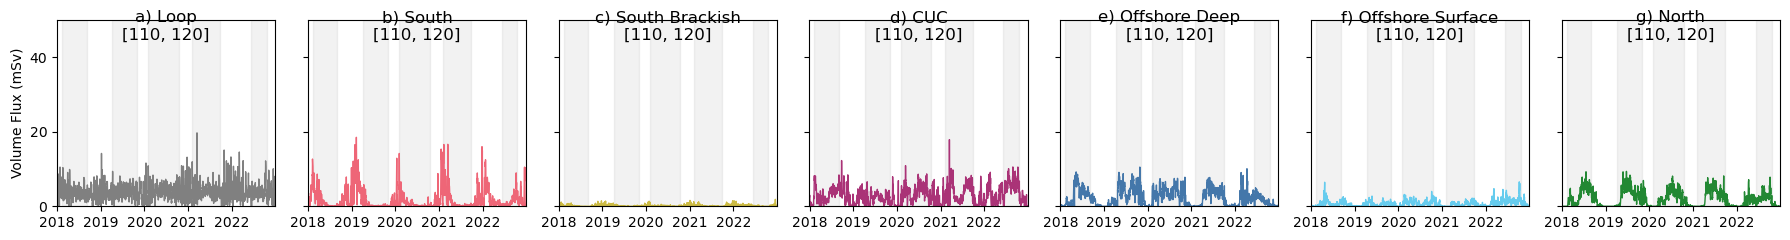

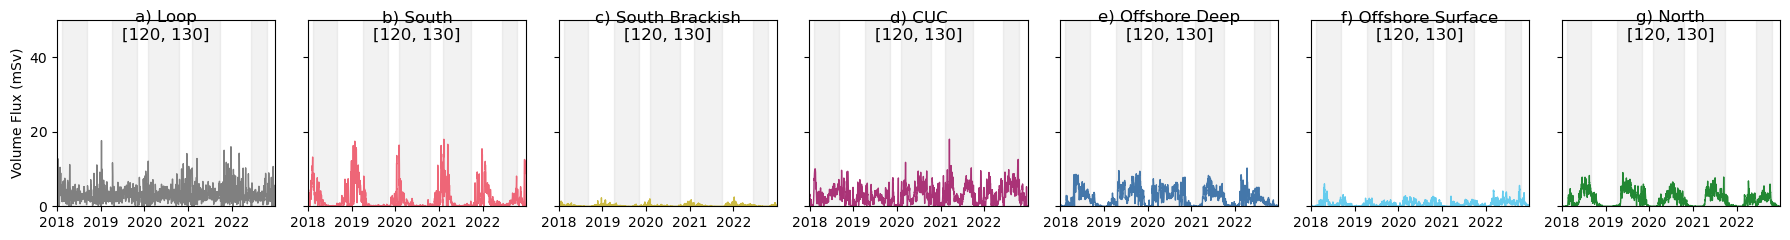

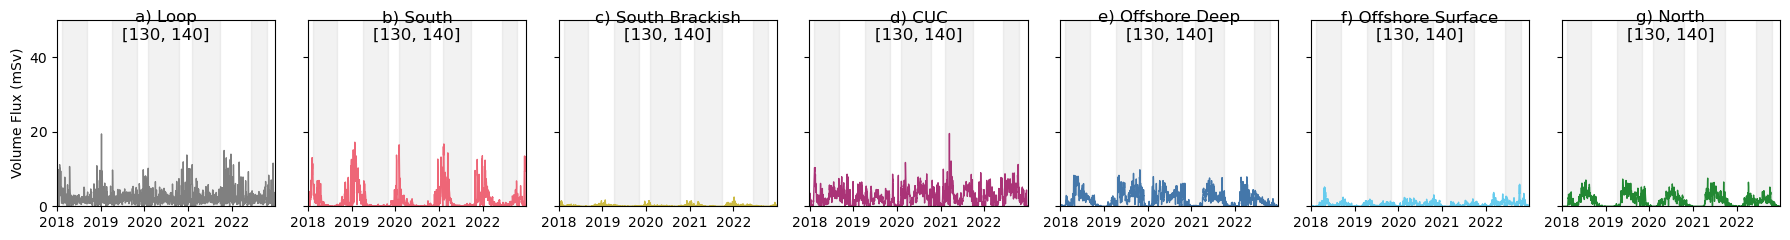

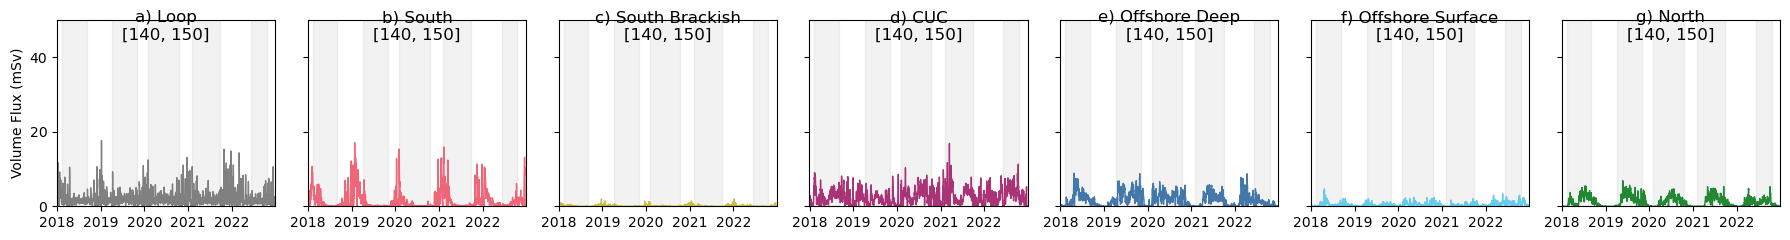

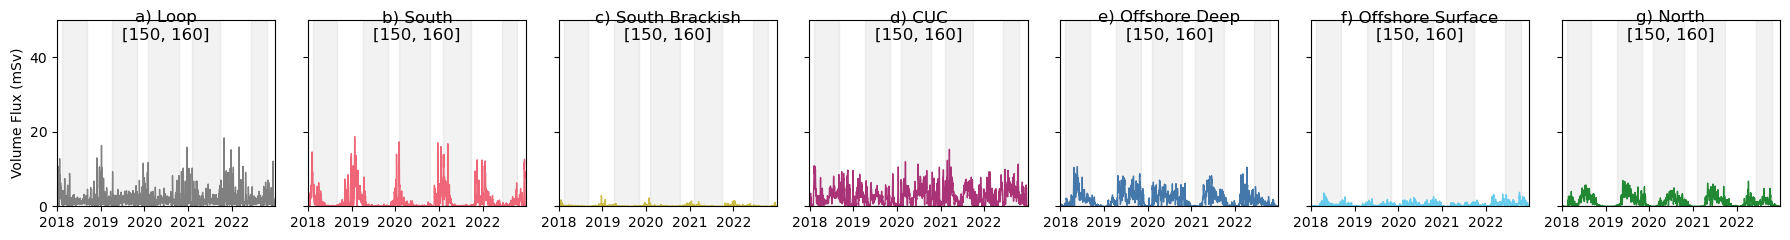

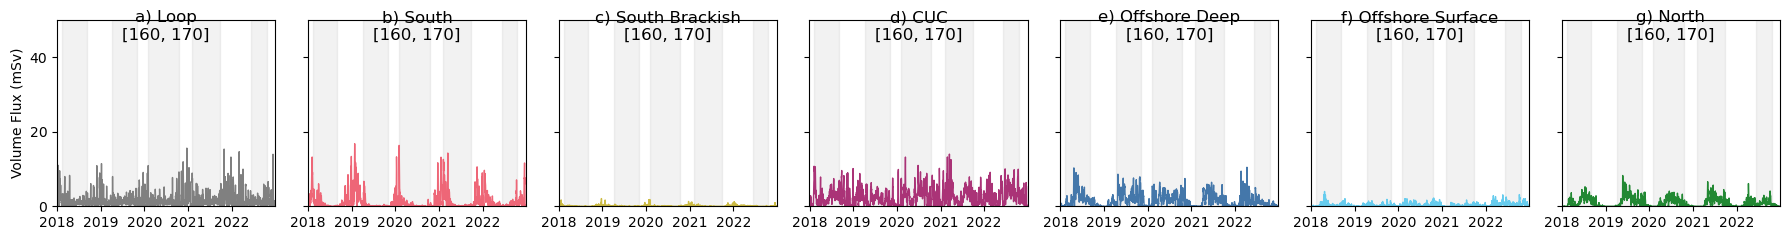

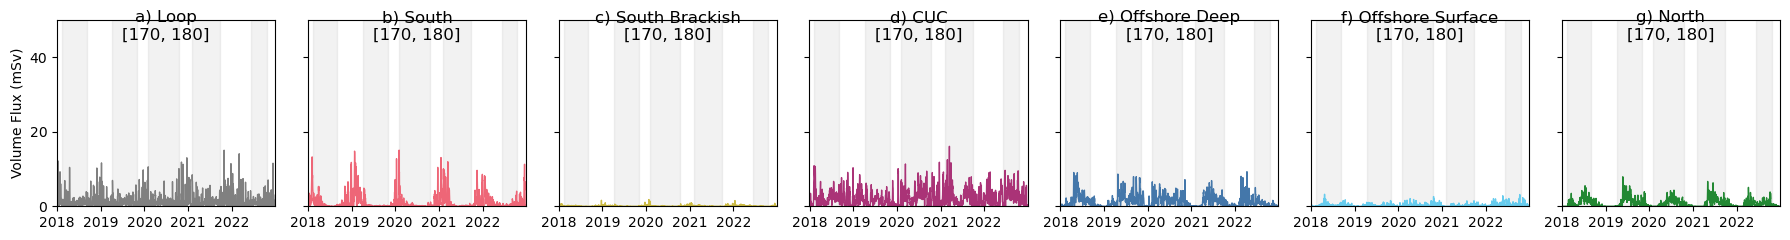

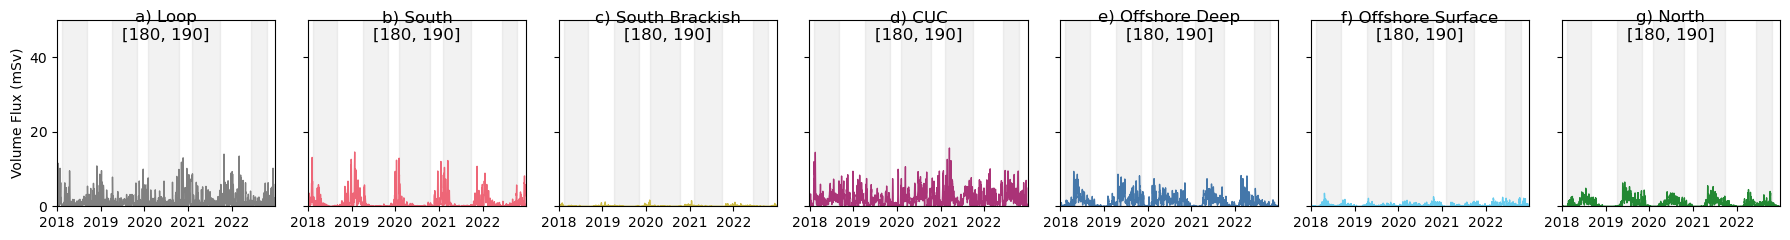

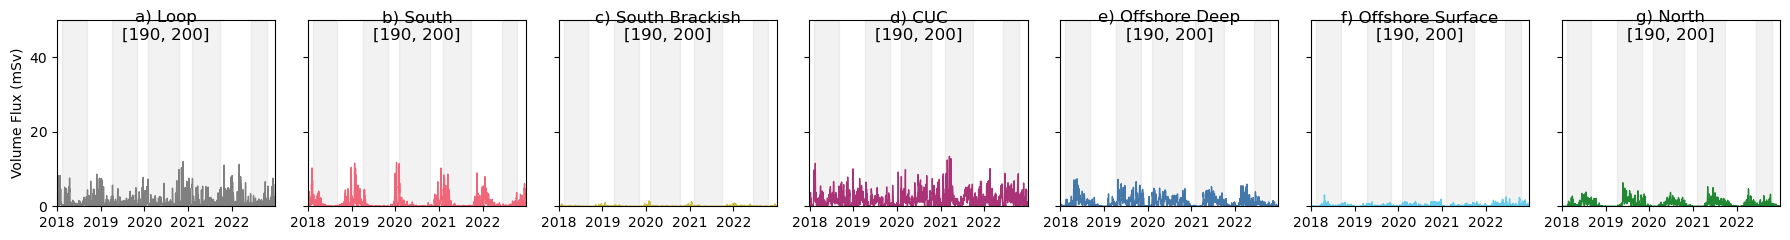

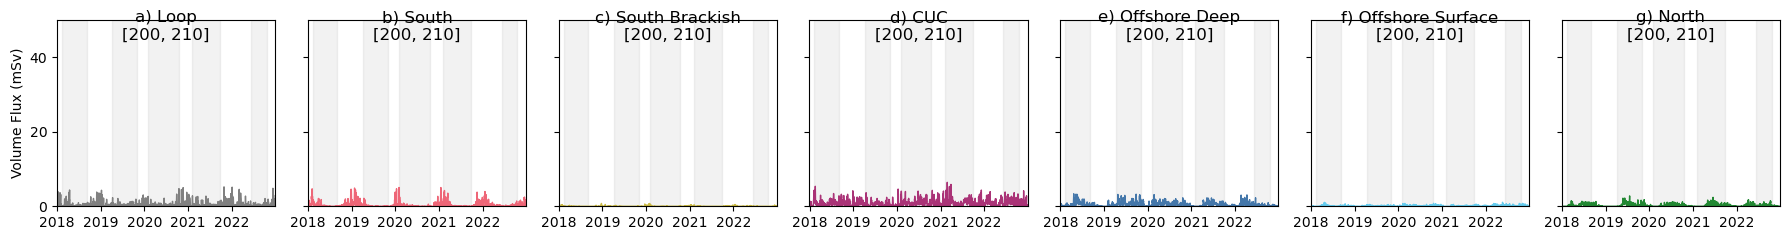

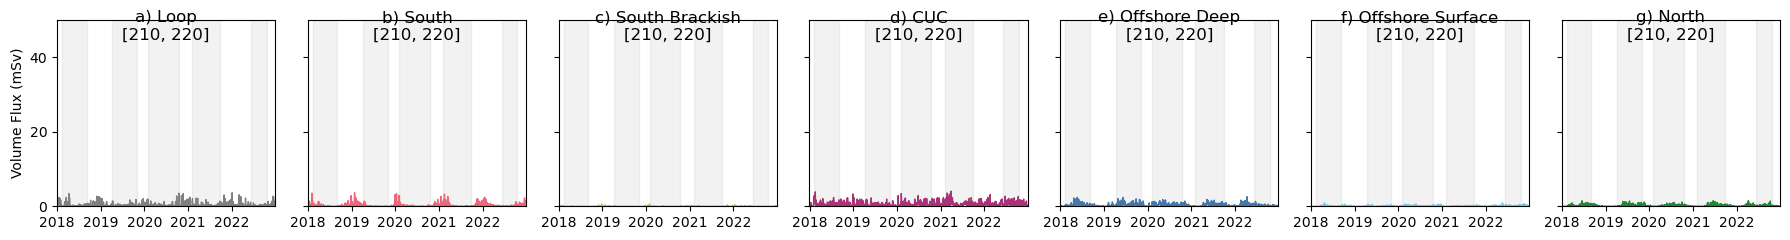

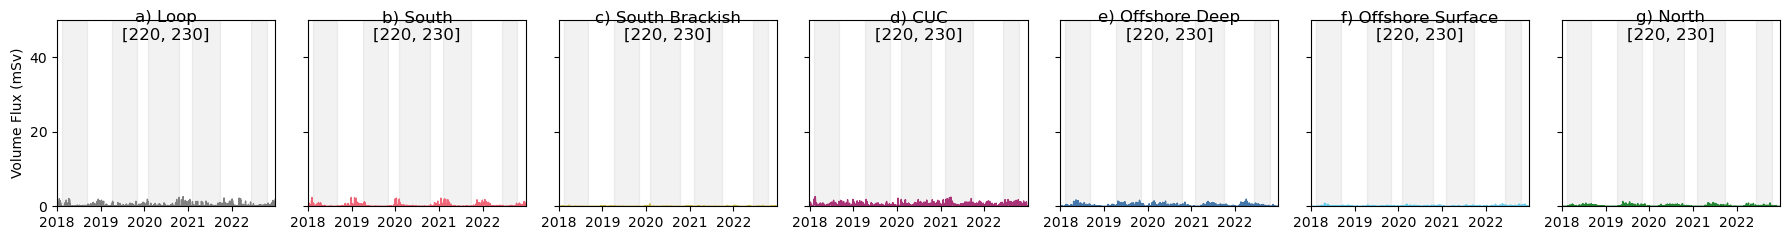

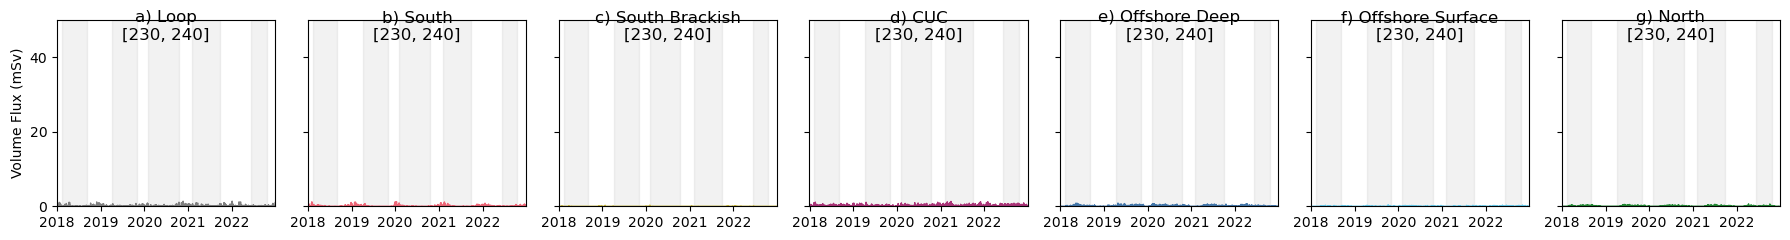

In [ ]:
# plot data from each water mass over the full water column
ymax=50000
depths=np.arange(0,np.max(data.Idepth+10),10)
startday=dt.datetime(2018,1,1) 
endday=dt.datetime(2022,12,31)

for d in range(len(depths)-1):
    depthrange=[int(depths[d]),int(depths[d+1])]

    fig, ax = plt.subplots(1,7, figsize=(18,2.5))

    # loop flow
    transport, dates = transport_array(data, depthrange, "loop")
    ax[0].plot(dates,transport,'grey',lw=1)
    ax[0].set_title('a) Loop\n'+str(depthrange),y=1,pad=-14)

    # south shelf flow
    transport, _ = transport_array(data, depthrange, "south")
    ax[1].plot(dates,transport,'#EE6677',lw=1)
    ax[1].set_title('b) South\n'+str(depthrange),y=1,pad=-14)

    # south brackish flow
    transport, _ = transport_array(data, depthrange, "fresh")
    ax[2].plot(dates,transport,'#CCBB44',lw=1)
    ax[2].set_title('c) South Brackish\n'+str(depthrange),y=1,pad=-14)

    # cuc flow
    transport, _ = transport_array(data, depthrange, "cuc")
    ax[3].plot(dates,transport,'#AA3377',lw=1)
    ax[3].set_title('d) CUC\n'+str(depthrange),y=1,pad=-14)

    # offshore deep flow
    transport, _ = transport_array(data, depthrange, "offshore_d")
    ax[4].plot(dates,transport,'#4477AA',lw=1)
    ax[4].set_title('e) Offshore Deep\n'+str(depthrange),y=1,pad=-14)

    # offshore surface flow
    transport, _ = transport_array(data, depthrange, "offshore_s")
    ax[5].plot(dates,transport,'#66CCEE',lw=1)
    ax[5].set_title('f) Offshore Surface\n'+str(depthrange),y=1,pad=-14)

    # north flow
    transport, _ = transport_array(data, depthrange, "north")
    ax[6].plot(dates,transport,'#228833',lw=1)
    ax[6].set_title('g) North\n'+str(depthrange),y=1,pad=-14)


    for i in range(len(ax)):
        # highlight upwelling periods based on Hourston and Thomson SOPO results
        for j in range(len(spring)):
            ax[i].fill_between(dates, 0, ymax, where=(dates<fall[j])&(dates>=spring[j]), color='grey', alpha=0.1)

        #general formatting
        ax[i].set_yticks([0,20000,40000])
        ax[i].set_yticklabels([])
        ax[i].set_ylim([0,ymax])
        ax[i].set_xlim([startday,endday])
        ax[i].set_xticks(pd.date_range(start=startday-dt.timedelta(days=365),end=endday-dt.timedelta(days=365), freq="Y")+dt.timedelta(days=1)+dt.timedelta(days=1))
        ax[i].set_xticklabels([2018,2019,2020,2021,2022])
    ax[0].set_yticklabels(['0','20','40'])
    ax[0].set_ylabel('Volume Flux (mSv)')

    plt.tight_layout()

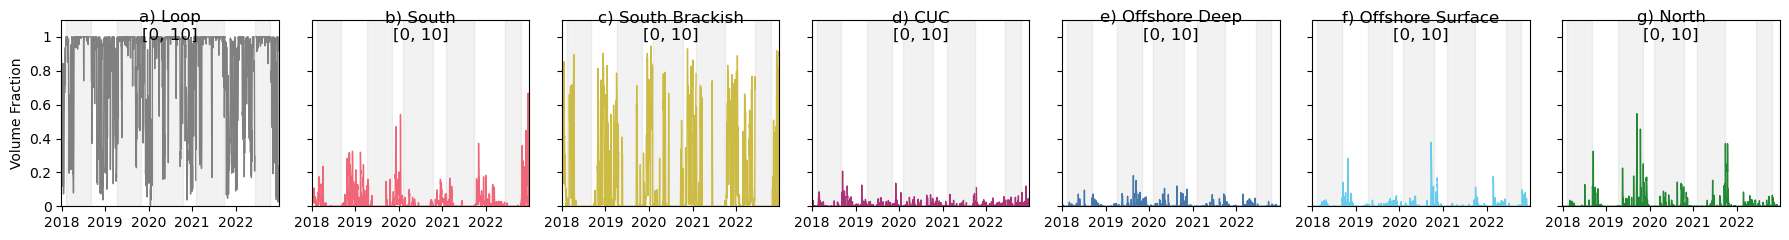

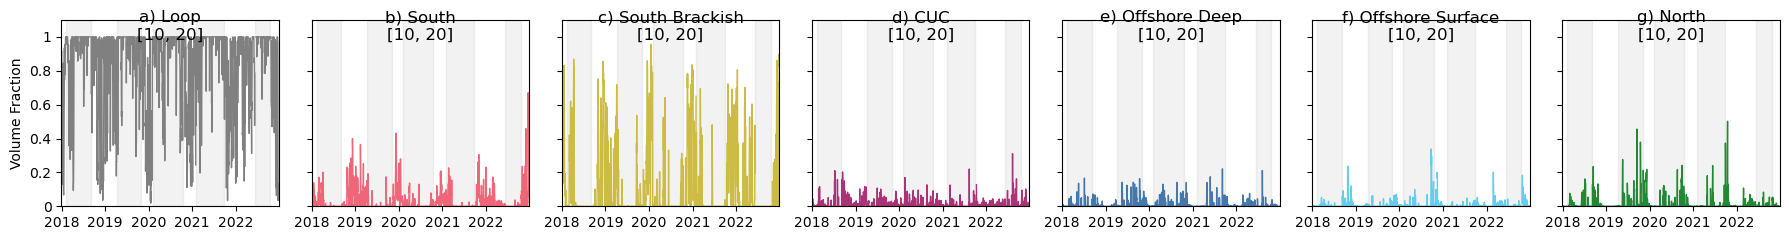

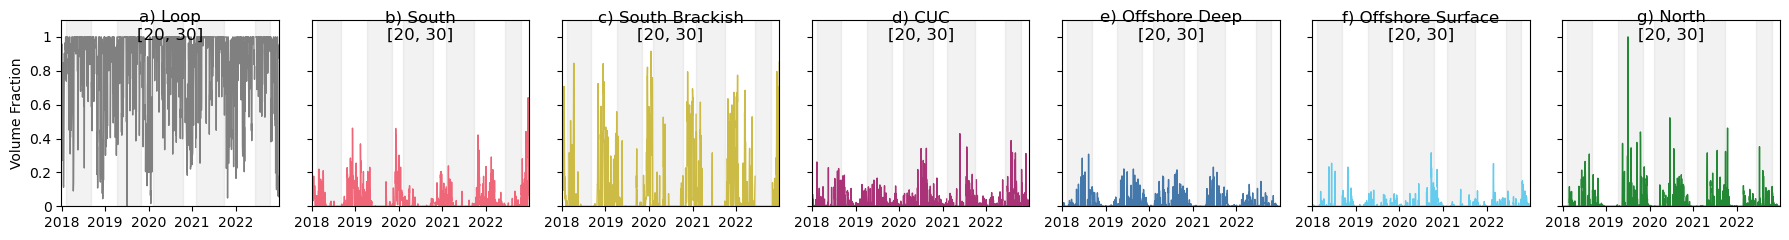

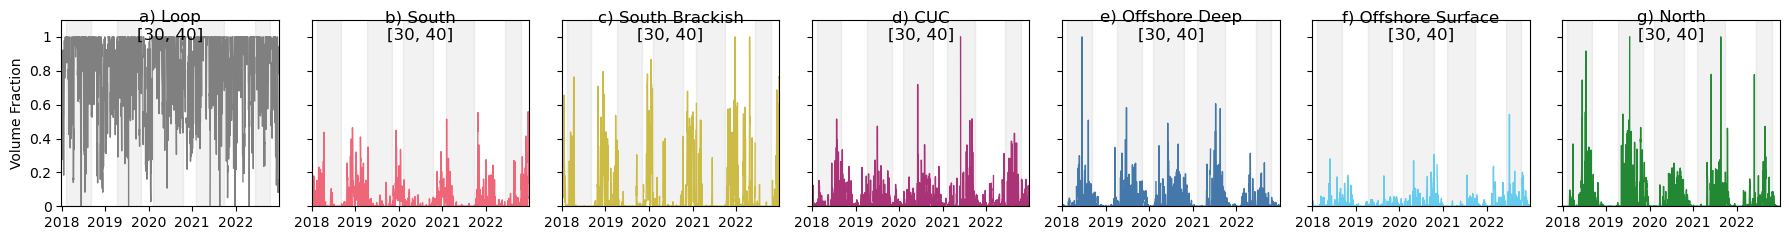

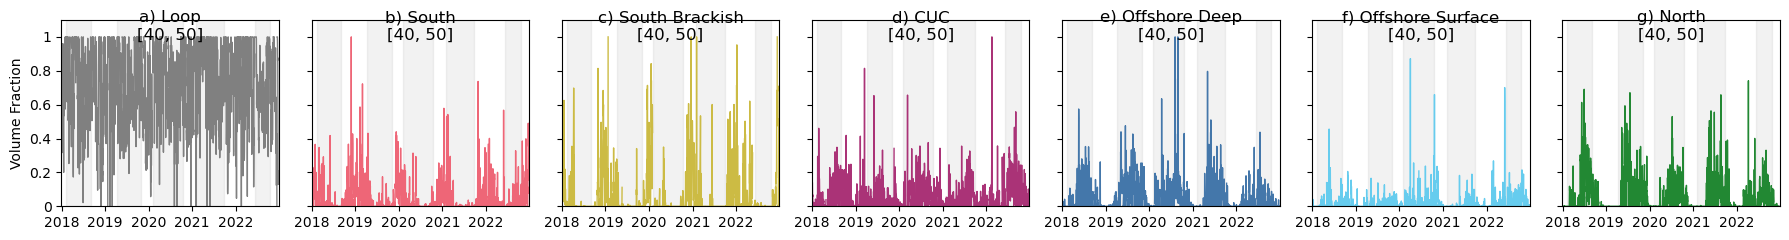

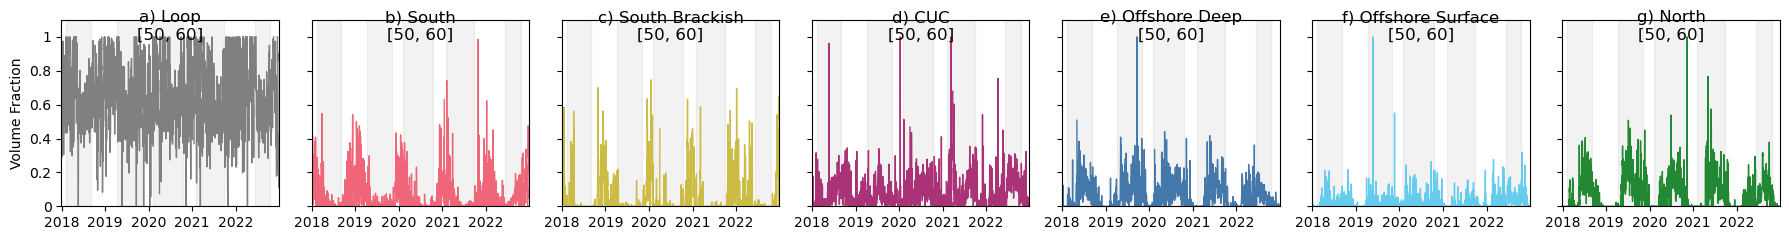

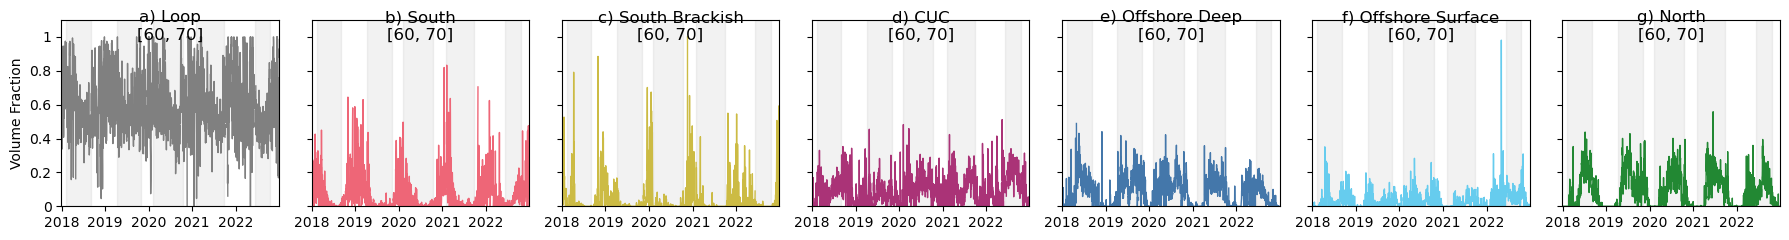

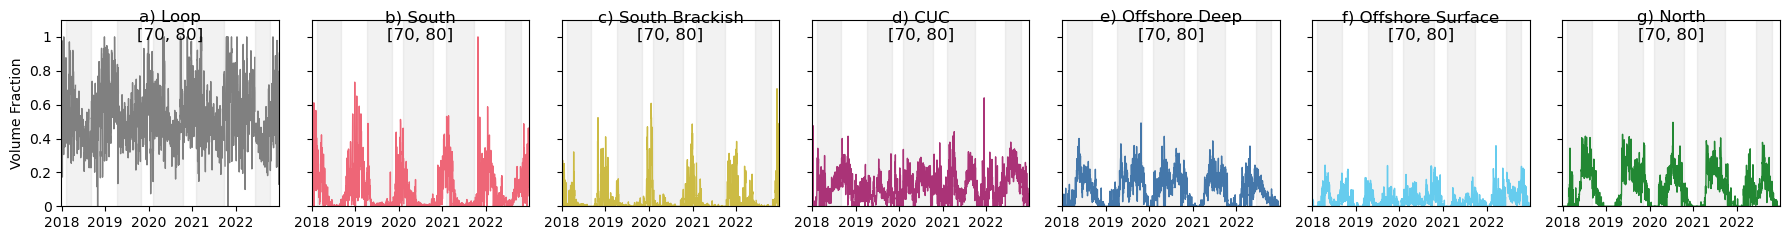

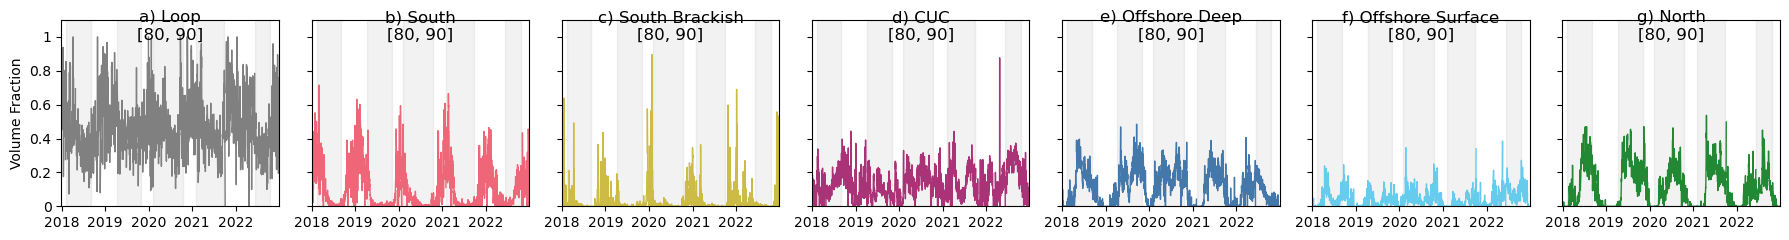

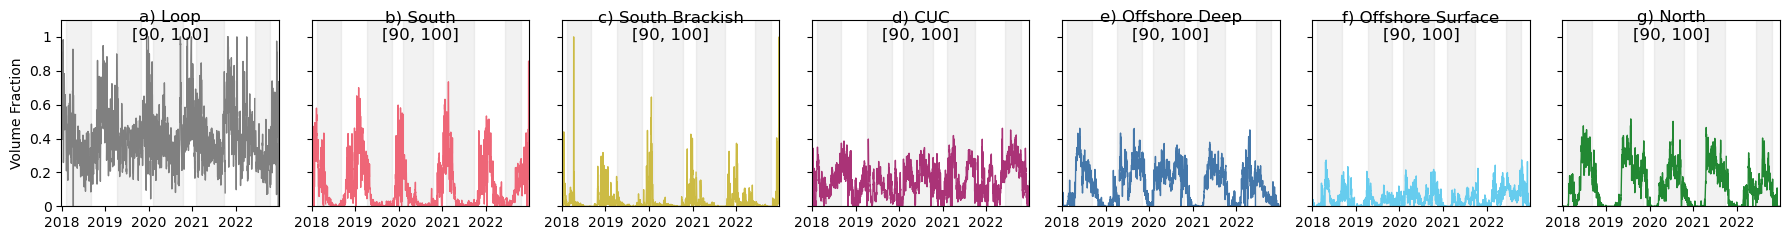

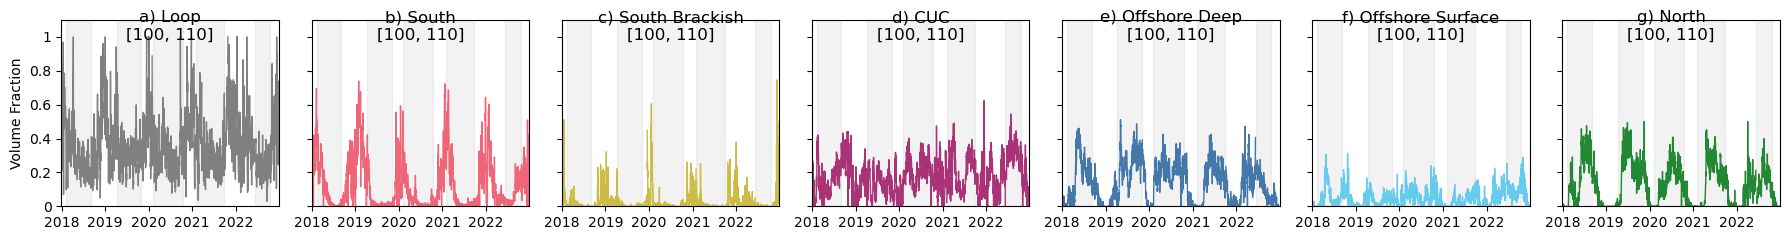

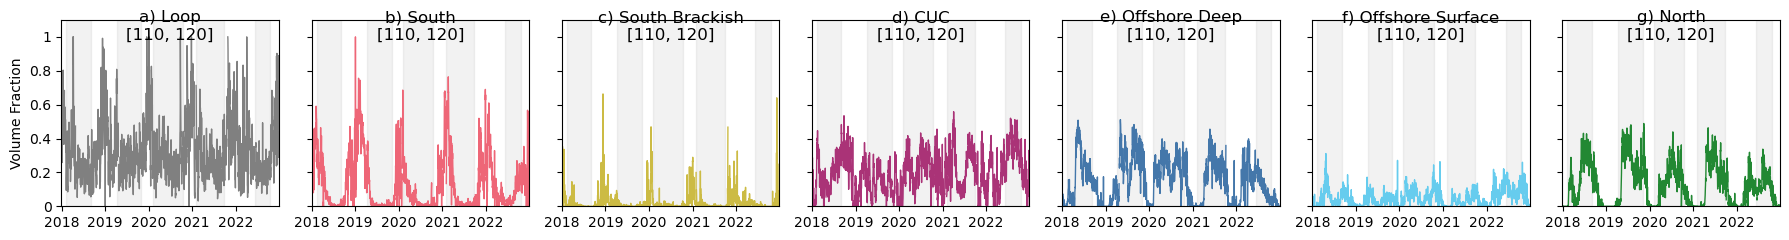

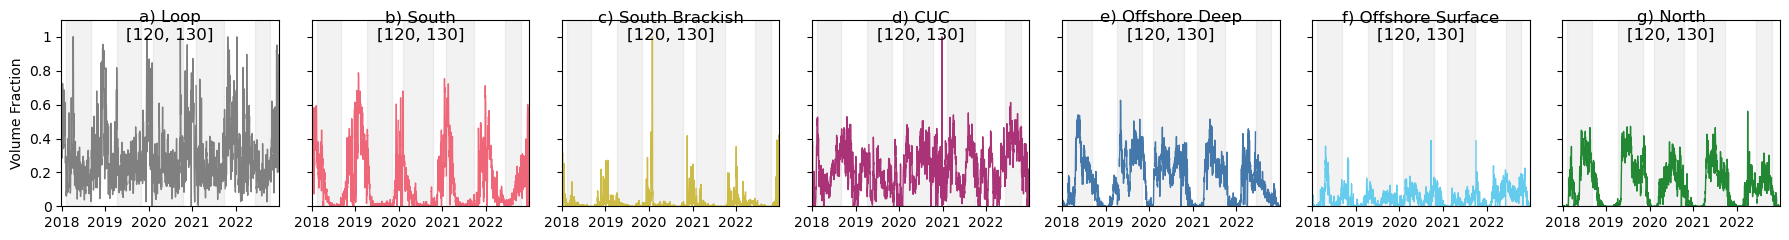

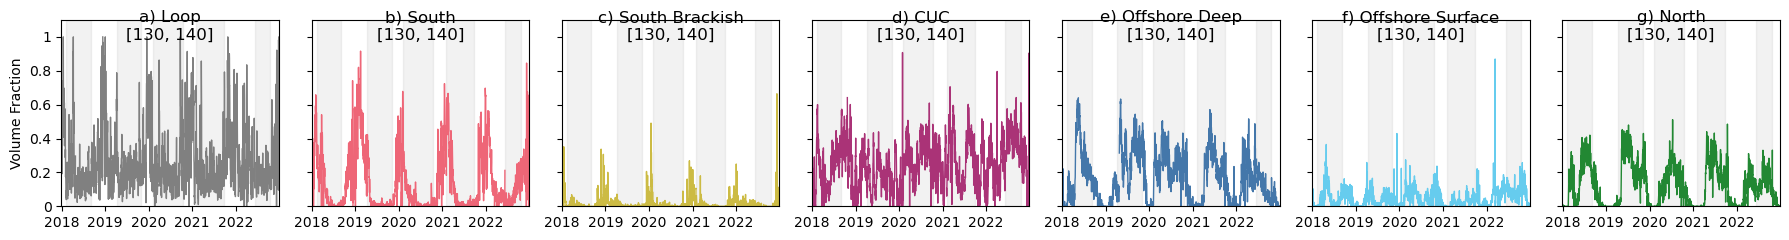

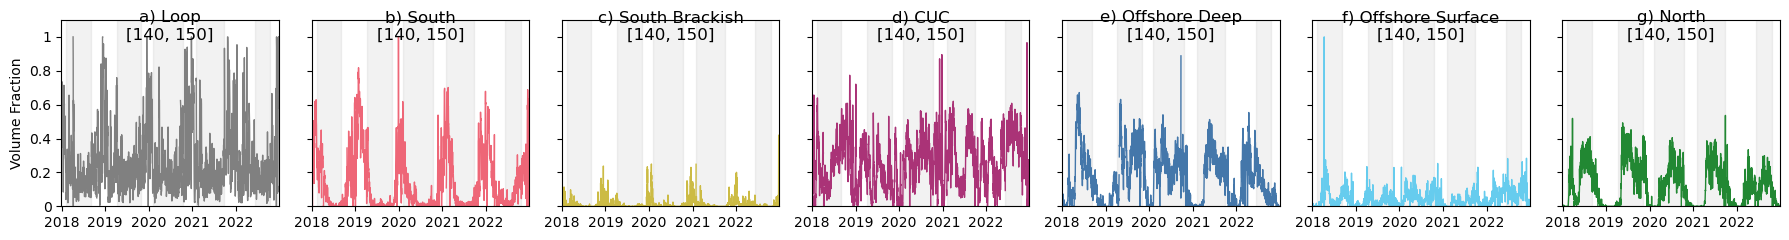

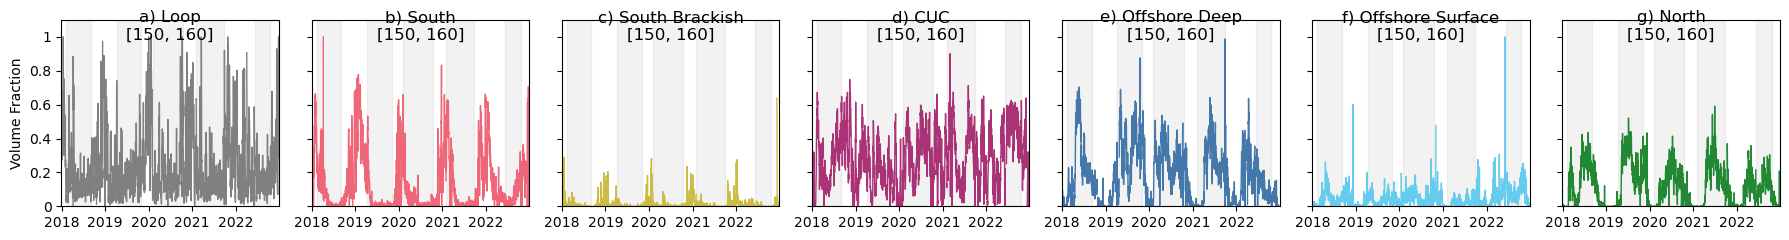

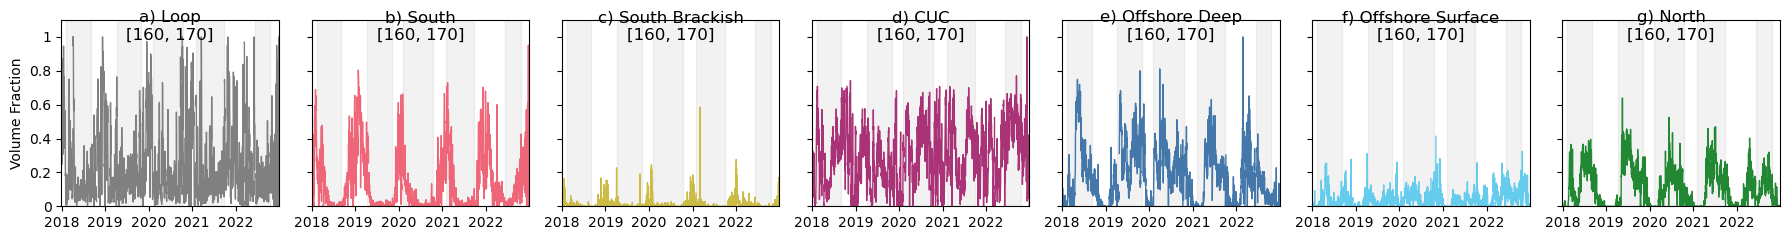

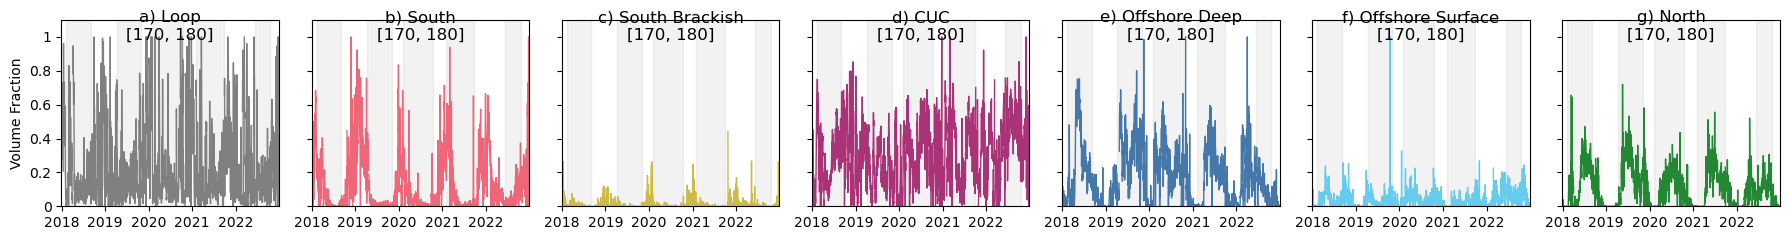

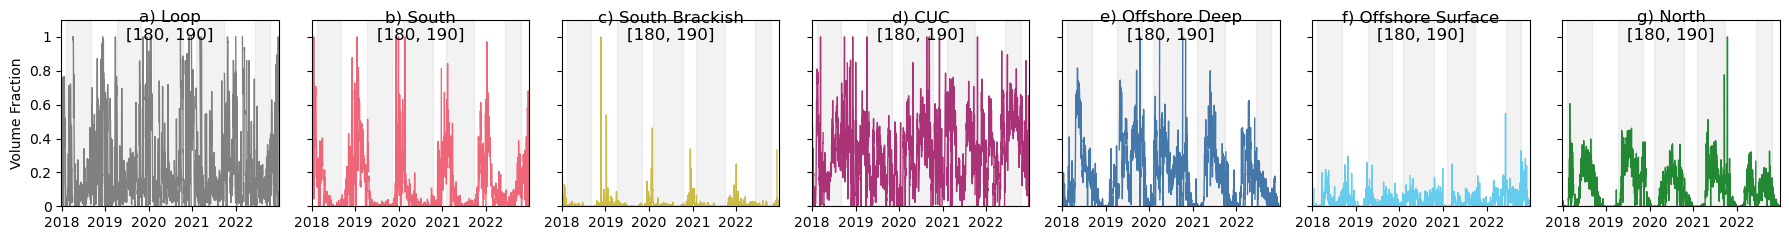

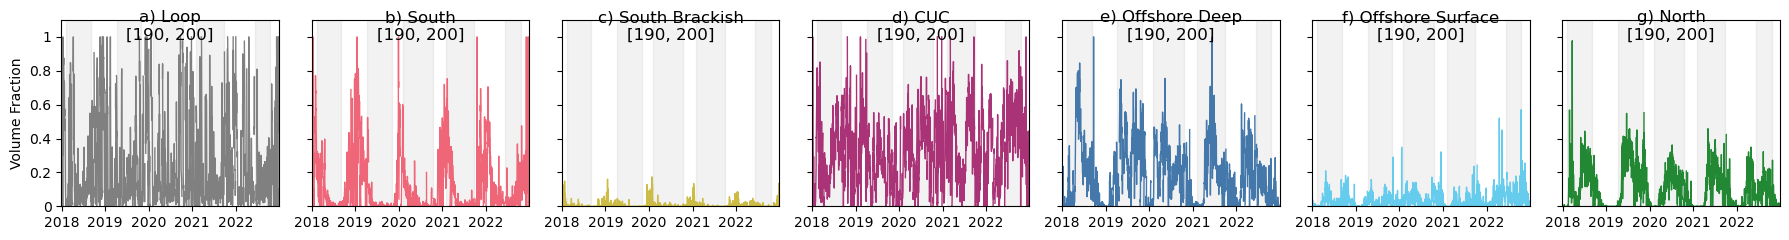

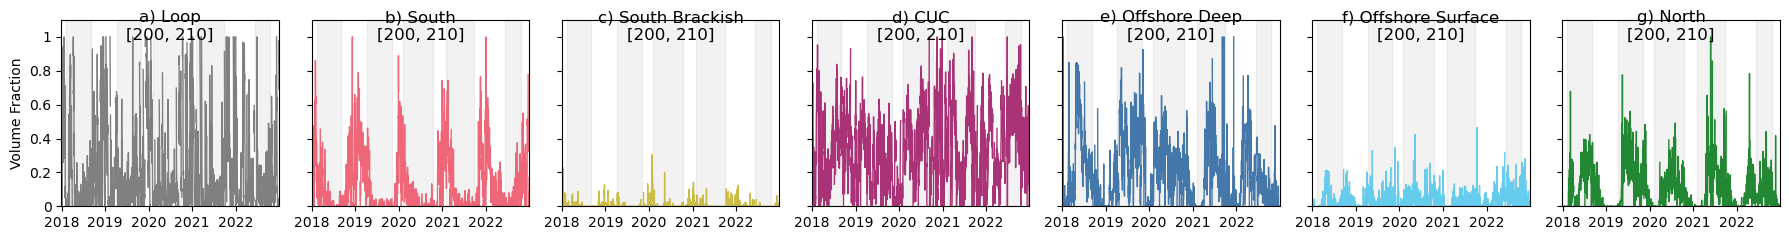

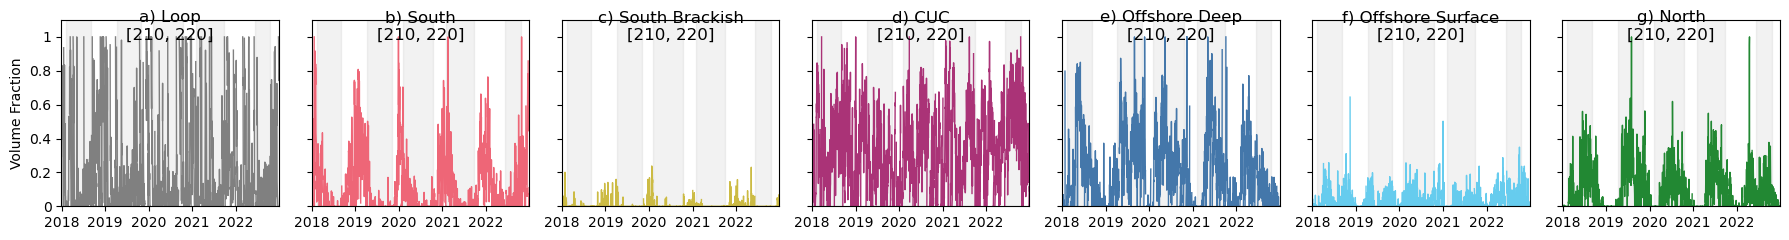

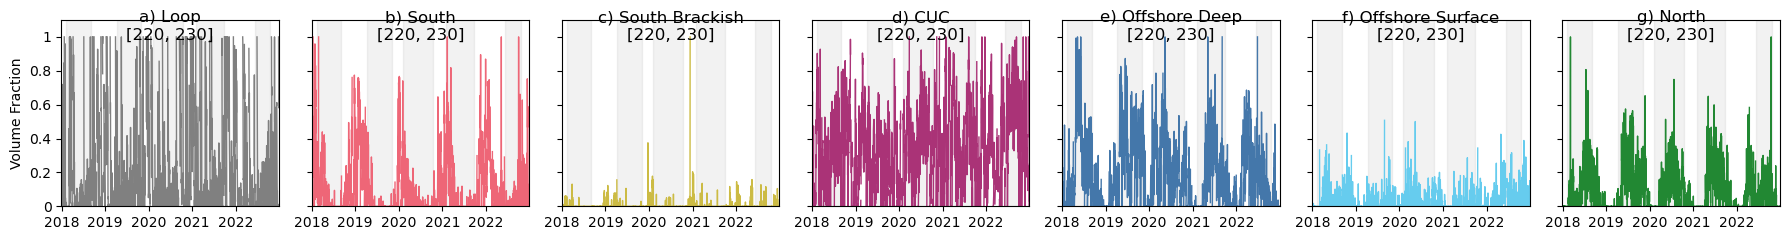

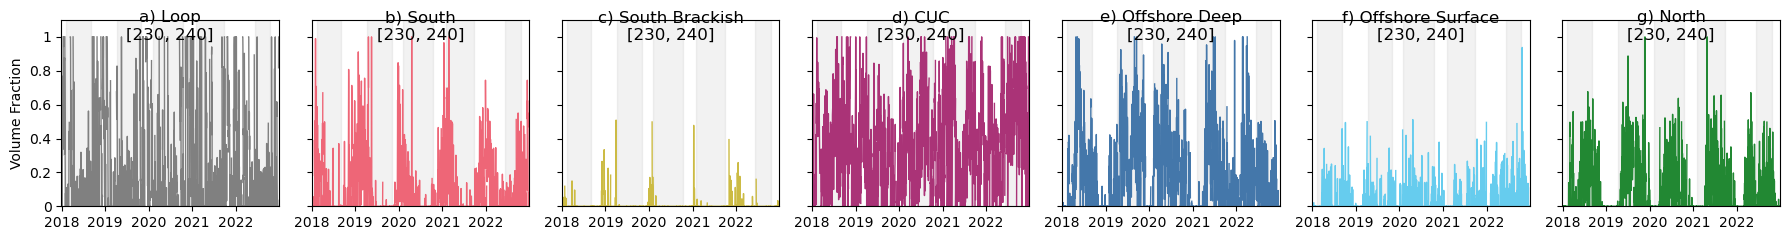

In [95]:
# same thing but as a percentage of the total inflow at that depth range

# plot data from each water mass over the full water column
ymax=1.1
depths=np.arange(0,np.max(data.Idepth+10),10)
startday=dt.datetime(2018,1,1) 
endday=dt.datetime(2022,12,31)

for d in range(len(depths)-1):
    depthrange=[int(depths[d]),int(depths[d+1])]
    total, dates = transport_array(data, depthrange, "total")

    fig, ax = plt.subplots(1,7, figsize=(18,2.5))

    # loop flow
    transport, _ = transport_array(data, depthrange, "loop")
    ax[0].plot(dates,transport/total,'grey',lw=1)
    ax[0].set_title('a) Loop\n'+str(depthrange),y=1,pad=-14)

    # south shelf flow
    transport, _ = transport_array(data, depthrange, "south")
    ax[1].plot(dates,transport/total,'#EE6677',lw=1)
    ax[1].set_title('b) South\n'+str(depthrange),y=1,pad=-14)

    # south brackish flow
    transport, _ = transport_array(data, depthrange, "fresh")
    ax[2].plot(dates,transport/total,'#CCBB44',lw=1)
    ax[2].set_title('c) South Brackish\n'+str(depthrange),y=1,pad=-14)

    # cuc flow
    transport, _ = transport_array(data, depthrange, "cuc")
    ax[3].plot(dates,transport/total,'#AA3377',lw=1)
    ax[3].set_title('d) CUC\n'+str(depthrange),y=1,pad=-14)

    # offshore deep flow
    transport, _ = transport_array(data, depthrange, "offshore_d")
    ax[4].plot(dates,transport/total,'#4477AA',lw=1)
    ax[4].set_title('e) Offshore Deep\n'+str(depthrange),y=1,pad=-14)

    # offshore surface flow
    transport, _ = transport_array(data, depthrange, "offshore_s")
    ax[5].plot(dates,transport/total,'#66CCEE',lw=1)
    ax[5].set_title('f) Offshore Surface\n'+str(depthrange),y=1,pad=-14)

    # north flow
    transport, _ = transport_array(data, depthrange, "north")
    ax[6].plot(dates,transport/total,'#228833',lw=1)
    ax[6].set_title('g) North\n'+str(depthrange),y=1,pad=-14)


    for i in range(len(ax)):
        # highlight upwelling periods based on Hourston and Thomson SOPO results
        for j in range(len(spring)):
            ax[i].fill_between(dates, 0, ymax, where=(dates<fall[j])&(dates>=spring[j]), color='grey', alpha=0.1)

        #general formatting
        ax[i].set_yticks([0,0.2,0.4,0.6,0.8,1])
        ax[i].set_yticklabels([])
        ax[i].set_ylim([0,ymax])
        ax[i].set_xlim([startday,endday])
        ax[i].set_xticks(pd.date_range(start=startday-dt.timedelta(days=365),end=endday-dt.timedelta(days=365), freq="Y")+dt.timedelta(days=1)+dt.timedelta(days=1))
        ax[i].set_xticklabels([2018,2019,2020,2021,2022])
    ax[0].set_yticklabels([0,0.2,0.4,0.6,0.8,1])
    ax[0].set_ylabel('Volume Fraction')

    plt.tight_layout()